In [1]:
import pandas as pd
import numpy as np

print("Successfully Installed!")

Successfully Installed!


In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\vedan\OneDrive\Desktop\Data_Analyst\loan_data.csv")
# Show first 5 rows
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [5]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

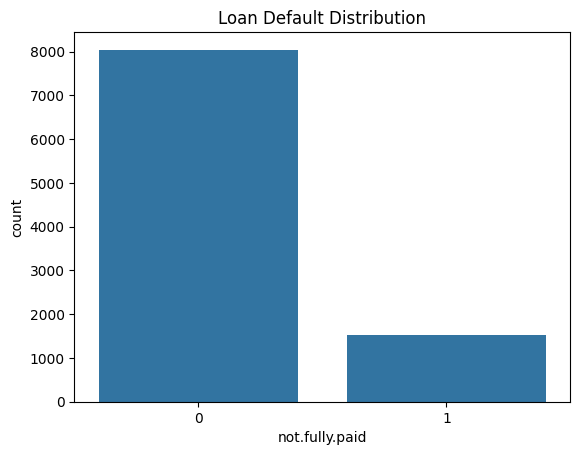

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='not.fully.paid', data=df)
plt.title("Loan Default Distribution")
plt.show()

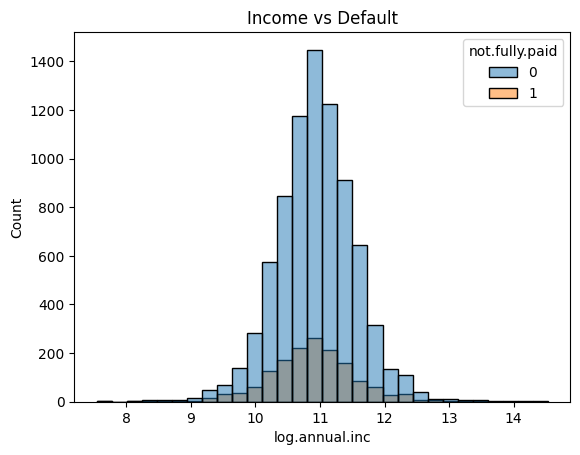

In [7]:
sns.histplot(data=df, x='log.annual.inc', hue='not.fully.paid', bins=30)
plt.title("Income vs Default")
plt.show()

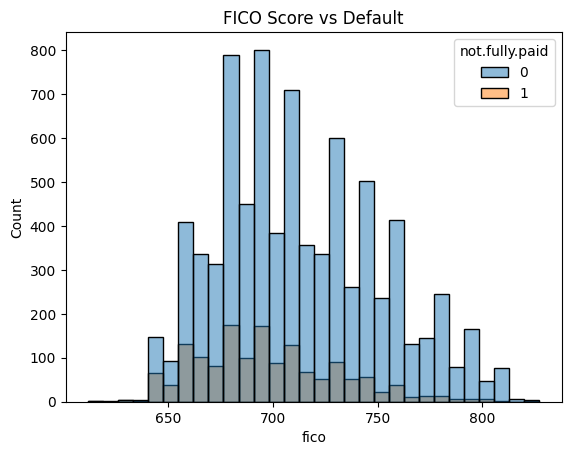

In [8]:
sns.histplot(data=df, x='fico', hue='not.fully.paid', bins=30)
plt.title("FICO Score vs Default")
plt.show()

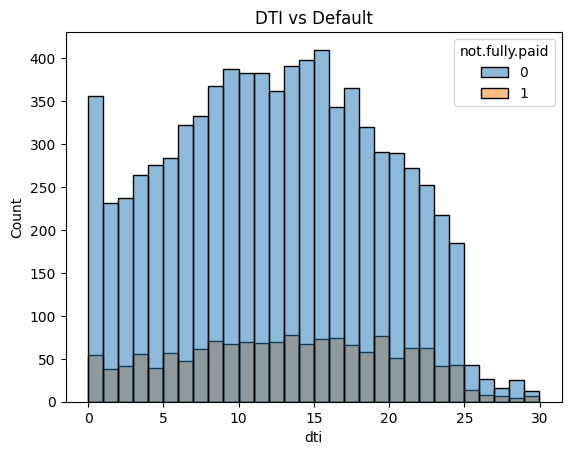

In [9]:
sns.histplot(data=df, x='dti', hue='not.fully.paid', bins=30)
plt.title("DTI vs Default")
plt.show()

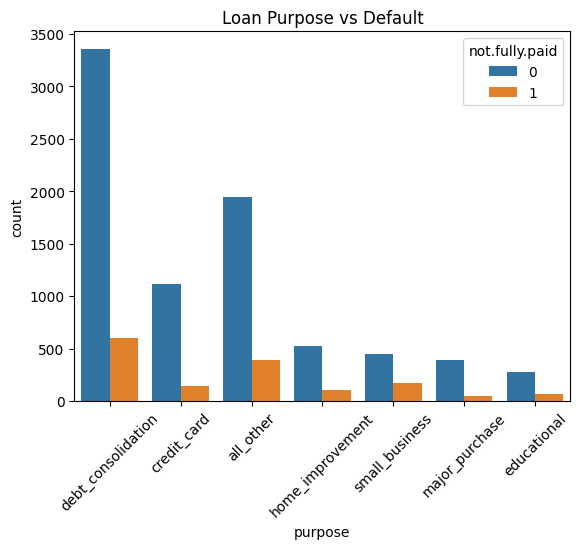

In [10]:
sns.countplot(x='purpose', hue='not.fully.paid', data=df)
plt.xticks(rotation=45)
plt.title("Loan Purpose vs Default")
plt.show()

In [12]:
df['loan_to_income'] = df['installment'] / df['log.annual.inc']
df['credit_stress'] = df['revol.util'] * df['dti']
df['risk_score'] = df['fico'] / (df['dti'] + 1)

In [13]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,loan_to_income,credit_stress,risk_score
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,73.045842,1014.908,35.986328
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,20.593491,1096.043,46.239372
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,35.365143,297.728,53.998416
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,14.302571,592.920,78.241758
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,9.108180,591.315,41.765811


In [14]:
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

In [15]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
print(X_train.shape)
print(X_test.shape)

(6704, 21)
(2874, 21)


In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression()

In [25]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test)

In [27]:
y_prob = model.predict_proba(X_test)

In [28]:
y_pred[:5]

array([0, 0, 0, 0, 0])

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8382045929018789


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2408
           1       0.52      0.03      0.06       466

    accuracy                           0.84      2874
   macro avg       0.68      0.51      0.48      2874
weighted avg       0.79      0.84      0.77      2874



In [31]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[2395   13]
 [ 452   14]]


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.65      0.76      2408
           1       0.26      0.63      0.37       466

    accuracy                           0.65      2874
   macro avg       0.58      0.64      0.56      2874
weighted avg       0.80      0.65      0.69      2874

[[1570  838]
 [ 173  293]]


In [34]:
y_prob = model.predict_proba(X_test)[:, 1]

In [35]:
import pandas as pd

output = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Risk_Probability': y_prob
})

In [36]:
output['Risk_Level'] = output['Risk_Probability'].apply(
    lambda x: 'High Risk' if x > 0.5 else 'Low Risk'
)

In [37]:
output.head()

,Actual,Predicted,Risk_Probability,Risk_Level
0,0,1,0.723248,High Risk
1,0,0,0.433824,Low Risk
2,1,0,0.404330,Low Risk
3,0,1,0.610884,High Risk
4,0,0,0.350611,Low Risk


In [38]:
output.to_csv("loan_risk_output.csv", index=False)

In [39]:
output['Risk_Level'] = output['Risk_Probability'].apply(
    lambda x: 'High Risk' if x > 0.3 else 'Low Risk'
)

In [40]:
output.to_csv("loan_risk_output.csv", index=False)